# Lab 11: Active Contour (Snake) Segmentation Case Studies

---

## Question 1: Skin Lesion Boundary Detection

**Scenario:**
A dermatologist wants to identify the boundary of a skin lesion in a dermoscopic image. The lesion has irregular edges with varying intensity, making simple thresholding inaccurate.

**Tasks:**
- Load a dermoscopic skin lesion image.
- Enhance contrast and perform smoothing.
- Place an initial contour at the center of the lesion.
- Run the active contour algorithm.
- Compare segmentation results using two different parameter sets (high α vs high β).
- Submit both results with a brief analysis of parameter influence.

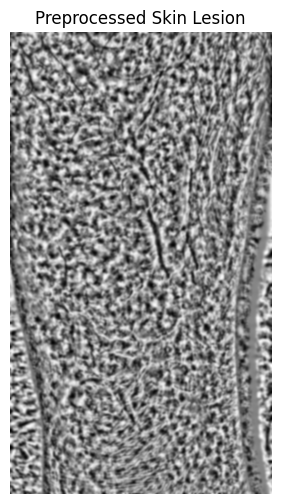

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, img_as_float
from skimage.segmentation import active_contour

# Load and preprocess the skin lesion image
img = img_as_float(io.imread('skin_lesion.jpg'))
if img.ndim == 3:
    img_gray = color.rgb2gray(img)
else:
    img_gray = img

# Enhance contrast and smooth
img_eq = filters.rank.equalize((img_gray * 255).astype(np.uint8), footprint=np.ones((30,30)))
img_smooth = filters.gaussian(img_eq, sigma=2)

# Display preprocessed image
plt.figure(figsize=(6,6))
plt.imshow(img_smooth, cmap='gray')
plt.title('Preprocessed Skin Lesion')
plt.axis('off')
plt.show()

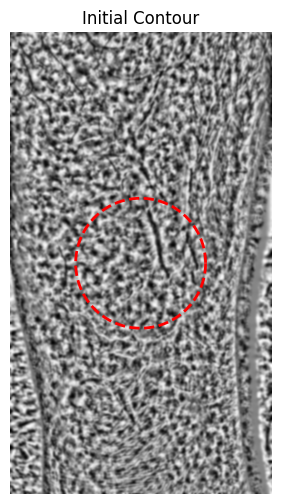

In [3]:
# Place initial contour (circle at center)
s = np.linspace(0, 2*np.pi, 400)
r = img_smooth.shape[0] // 2
c = img_smooth.shape[1] // 2
radius = min(r, c) // 2
init = np.array([r + radius*np.sin(s), c + radius*np.cos(s)]).T

plt.figure(figsize=(6,6))
plt.imshow(img_smooth, cmap='gray')
plt.plot(init[:, 1], init[:, 0], '--r', lw=2)
plt.title('Initial Contour')
plt.axis('off')
plt.show()

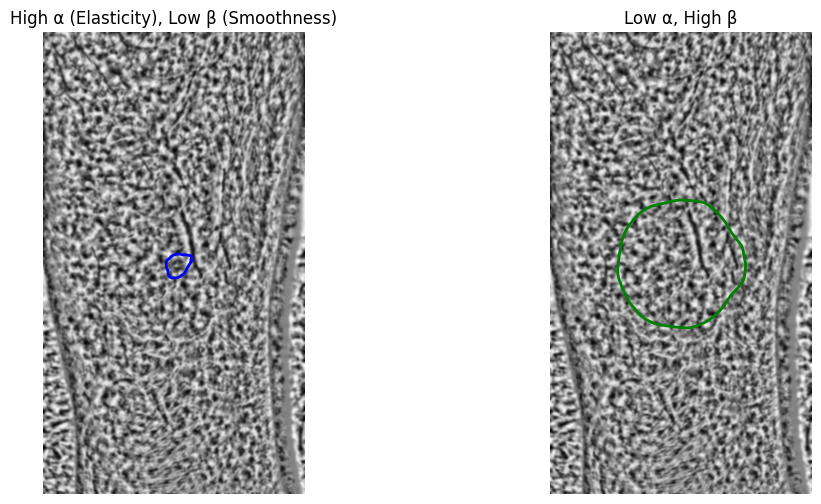

In [5]:
# Run active contour: high alpha (elasticity), low beta (smoothness)
snake1 = active_contour(img_smooth, init, alpha=0.8, beta=0.1, gamma=0.01, max_num_iter=300)

# Run active contour: low alpha, high beta
snake2 = active_contour(img_smooth, init, alpha=0.1, beta=1.0, gamma=0.01, max_num_iter=300)

# Display results
fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].imshow(img_smooth, cmap='gray')
ax[0].plot(snake1[:, 1], snake1[:, 0], '-b', lw=2)
ax[0].set_title('High α (Elasticity), Low β (Smoothness)')
ax[0].axis('off')
ax[1].imshow(img_smooth, cmap='gray')
ax[1].plot(snake2[:, 1], snake2[:, 0], '-g', lw=2)
ax[1].set_title('Low α, High β')
ax[1].axis('off')
plt.show()

**Analysis of Parameter Influence:**

- High α (elasticity) makes the contour more flexible, allowing it to fit irregular boundaries but may be sensitive to noise.
- High β (smoothness) enforces a smoother contour, which may miss fine details but is more robust to noise.
- In practice, a balance is needed: high α for irregular lesions, high β for smoother boundaries.

---

## Question 2: Fingerprint Ridge Boundary with Active Contour

**Scenario:**
A biometric fingerprint scan has broken ridge edges due to smudging. Simple edge detectors miss the correct ridge boundary.

**Tasks:**
- Load a fingerprint image.
- Preprocess: binarize and smooth.
- Apply active contour to trace a specific ridge boundary.
- Display evolution of the snake (initial, mid, final).
- Discuss how active contour helps reconstruct broken edges.

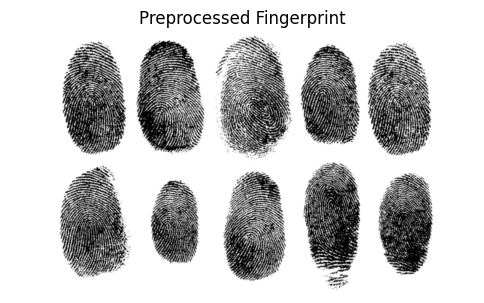

In [6]:
# Load and preprocess fingerprint image
img_fp = img_as_float(io.imread('fingerprint.jpg'))
if img_fp.ndim == 3:
    img_fp_gray = color.rgb2gray(img_fp)
else:
    img_fp_gray = img_fp

# Binarize and smooth
thresh = filters.threshold_otsu(img_fp_gray)
img_fp_bin = img_fp_gray > thresh
img_fp_smooth = filters.gaussian(img_fp_bin, sigma=1)

plt.figure(figsize=(6,6))
plt.imshow(img_fp_smooth, cmap='gray')
plt.title('Preprocessed Fingerprint')
plt.axis('off')
plt.show()

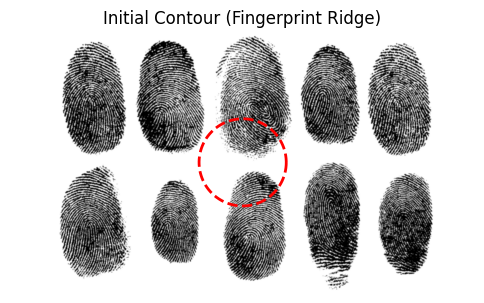

In [7]:
# Place initial contour (roughly along a ridge)
s = np.linspace(0, 2*np.pi, 200)
r = img_fp_smooth.shape[0] // 2
c = img_fp_smooth.shape[1] // 2
radius = min(r, c) // 3
init_fp = np.array([r + radius*np.sin(s), c + radius*np.cos(s)]).T

plt.figure(figsize=(6,6))
plt.imshow(img_fp_smooth, cmap='gray')
plt.plot(init_fp[:, 1], init_fp[:, 0], '--r', lw=2)
plt.title('Initial Contour (Fingerprint Ridge)')
plt.axis('off')
plt.show()

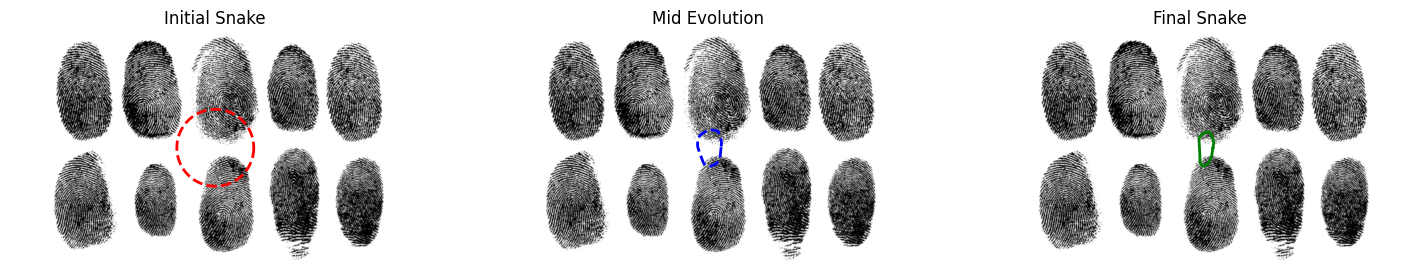

In [9]:
# Run active contour and show evolution
snake_fp_init = init_fp.copy()
snake_fp_mid = active_contour(img_fp_smooth, snake_fp_init, alpha=0.5, beta=0.5, gamma=0.01, max_num_iter=100)
snake_fp_final = active_contour(img_fp_smooth, snake_fp_mid, alpha=0.5, beta=0.5, gamma=0.01, max_num_iter=200)

fig, ax = plt.subplots(1,3, figsize=(18,6))
ax[0].imshow(img_fp_smooth, cmap='gray')
ax[0].plot(snake_fp_init[:, 1], snake_fp_init[:, 0], '--r', lw=2)
ax[0].set_title('Initial Snake')
ax[0].axis('off')
ax[1].imshow(img_fp_smooth, cmap='gray')
ax[1].plot(snake_fp_mid[:, 1], snake_fp_mid[:, 0], '--b', lw=2)
ax[1].set_title('Mid Evolution')
ax[1].axis('off')
ax[2].imshow(img_fp_smooth, cmap='gray')
ax[2].plot(snake_fp_final[:, 1], snake_fp_final[:, 0], '-g', lw=2)
ax[2].set_title('Final Snake')
ax[2].axis('off')
plt.show()

**Discussion:**

- Active contour (snake) models can reconstruct broken or weak edges by evolving the contour based on image gradients and internal forces.
- Unlike simple edge detectors, snakes can bridge gaps in ridges caused by smudging, noise, or incomplete boundaries.
- The snake is attracted to strong edges but can also interpolate across missing segments, resulting in a more complete and accurate ridge boundary.